In [42]:
%pip install numpy pandas pyarrow matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.


# Imports

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Overview

In [44]:
raw_df = pd.read_parquet("Processed_data/surface_test.parquet")

In [45]:
raw_df.sample(10, random_state=0)

,ticker,quote_date,expire_date,dte,tau,underlying_last,forward,strike,log_moneyness,type,bid,ask,mid,iv,total_var,delta,volume
251414,SPX,2023-10-04,2024-05-17,226.00,0.619178,4265.10,4265.10,3300.0,-0.256543,put,33.60,34.20,33.900,0.27118,0.045533,-0.07608,1.0
306831,SPX,2023-10-18,2023-10-27,9.00,0.024658,4314.09,4314.09,3400.0,-0.238111,put,0.50,0.60,0.550,0.56810,0.007958,-0.00470,40.0
95698,QQQ,2023-10-03,2023-10-20,17.00,0.046575,354.90,354.90,288.0,-0.208876,put,0.16,0.17,0.165,0.44213,0.009104,-0.01278,0.0
116886,QQQ,2023-10-18,2023-10-25,7.00,0.019178,363.07,363.07,381.0,0.048204,call,0.14,0.15,0.145,0.18104,0.000629,0.03837,80.0
258417,SPX,2023-10-06,2023-10-13,7.00,0.019178,4307.68,4307.68,4560.0,0.056923,call,0.05,0.15,0.100,0.14249,0.000389,0.00324,2.0
159758,QQQ,2023-11-16,2024-09-20,308.96,0.846466,385.96,385.96,245.0,-0.454476,put,1.71,1.87,1.790,0.32224,0.087896,-0.03505,0.0
673348,TSLA,2023-12-19,2024-05-17,149.96,0.410849,257.19,257.19,315.0,0.202758,call,13.80,14.00,13.900,0.46370,0.088340,0.32302,2.0
433865,SPX,2023-11-15,2024-01-31,77.00,0.210959,4503.53,4503.53,3420.0,-0.275221,put,4.30,4.50,4.400,0.30544,0.019681,-0.01816,10.0
94679,QQQ,2023-10-02,2024-03-15,165.00,0.452055,361.27,361.27,333.0,-0.081483,put,9.24,9.29,9.265,0.24688,0.027553,-0.24365,141.0
597624,SPX,2023-12-22,2024-01-05,14.00,0.038356,4755.11,4755.11,3400.0,-0.335444,put,0.05,0.10,0.075,0.52183,0.010445,-0.00022,116.0


In [46]:
raw_df.describe()

,quote_date,expire_date,dte,tau,underlying_last,forward,strike,log_moneyness,bid,ask,mid,iv,total_var,delta,volume
count,679076,679076,679076.000000,679076.000000,679076.000000,679076.000000,679076.000000,679076.000000,679076.000000,679076.000000,679076.000000,679076.000000,679076.000000,679076.000000,603420.000000
mean,2023-11-14 13:13:34.049678848,2024-02-14 22:27:52.291171840,92.384641,0.253109,2750.114128,2750.114128,2612.416091,-0.035544,21.514009,21.902237,21.708123,0.259605,0.021275,0.007277,93.107655
min,2023-10-02 00:00:00,2023-10-09 00:00:00,7.000000,0.019178,19.250000,19.250000,12.000000,-0.499850,0.010000,0.010000,0.010000,0.067650,0.000088,-0.547820,0.000000
25%,2023-10-23 00:00:00,2023-12-08 00:00:00,22.000000,0.060274,388.750000,388.750000,370.000000,-0.139391,0.950000,1.050000,1.000000,0.151240,0.002254,-0.116013,1.000000
50%,2023-11-14 00:00:00,2024-01-19 00:00:00,50.040000,0.137096,4247.700000,4247.700000,3620.000000,-0.030422,6.400000,6.600000,6.525000,0.213530,0.008128,-0.013940,5.000000
75%,2023-12-07 00:00:00,2024-03-28 00:00:00,140.960000,0.386192,4548.330000,4548.330000,4360.000000,0.053856,25.400000,25.900000,25.601250,0.340630,0.024122,0.087333,30.000000
max,2023-12-29 00:00:00,2024-12-20 00:00:00,365.000000,1.000000,4783.830000,4783.830000,7800.000000,0.499993,406.900000,413.300000,410.100000,1.378710,0.619220,0.637280,285772.000000
std,NaN,NaN,92.062820,0.252227,2045.845452,2045.845452,1970.825970,0.185964,37.423609,37.930346,37.676173,0.140484,0.033791,0.225502,794.899106


How many null entries are there?

In [47]:
raw_df.isna().sum() # number of null entries in each column

ticker                 0
quote_date             0
expire_date            0
dte                    0
tau                    0
underlying_last        0
forward                0
strike                 0
log_moneyness          0
type                   0
bid                    0
ask                    0
mid                    0
iv                     0
total_var              0
delta                  0
volume             75656
dtype: int64

# Distribution Exploration

## Column: `ticker`
What tickers are covered, and how well?

In [48]:
for ticker, count in raw_df["ticker"].value_counts().items():
    print(f"There are {count:<6} observations of {ticker}")

There are 396689 observations of SPX
There are 120727 observations of QQQ
There are 68550  observations of NVDA
There are 48637  observations of TSLA
There are 24677  observations of AAPL
There are 19796  observations of SLV


## Time Columns: `quote_date`, `expire_date`, `dte`, and `tau`

`tau` appears to simply be a rescaled version of `dte`:

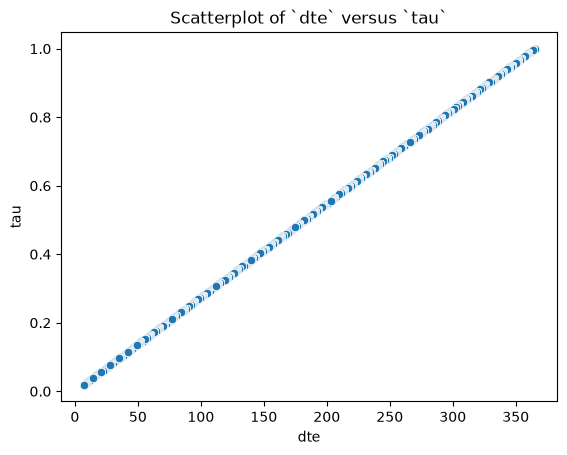

In [49]:
sns.scatterplot(data=raw_df, x="dte", y="tau")
plt.title("Scatterplot of `dte` versus `tau`");

Likewise, `dte` appears to be just the difference between `expire_date` and `quote_date`, up to scaling.

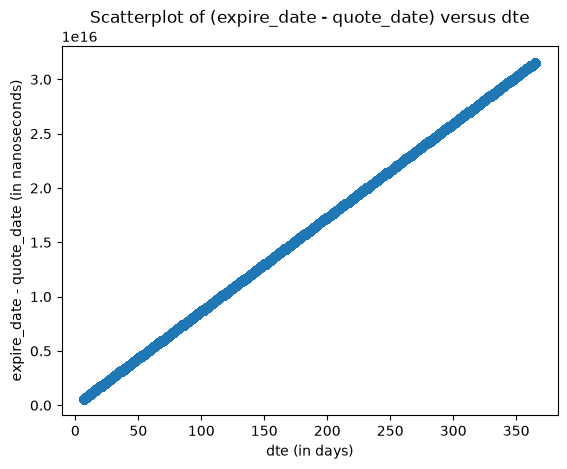

In [50]:
plt.scatter(raw_df["dte"], (raw_df["expire_date"] - raw_df["quote_date"]).values.astype(int))
plt.title("Scatterplot of (expire_date - quote_date) versus dte")
plt.xlabel("dte (in days)")
plt.ylabel("expire_date - quote_date (in nanoseconds)");

So, when modeling, we only need to use two of these columns. The most logical choice seems to be `tau` and `quote_date`.

## Stock Price Columns: `underlying_last`, `forward`, `strike`

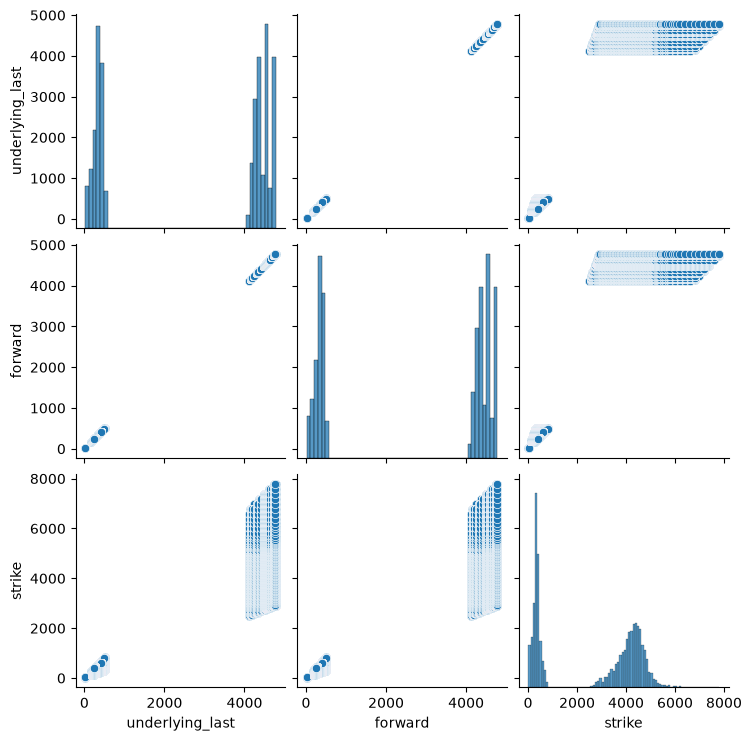

In [51]:
sns.pairplot(raw_df[["underlying_last", "forward", "strike"]]);

## Column: `log_moneyness`

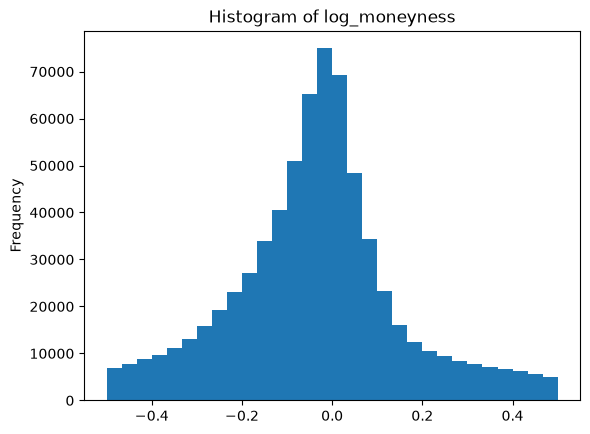

In [52]:
raw_df["log_moneyness"].plot(kind="hist", bins=30)
plt.title("Histogram of log_moneyness");

`log_moneyness` appears to be calculated using `forward` as the spot price:

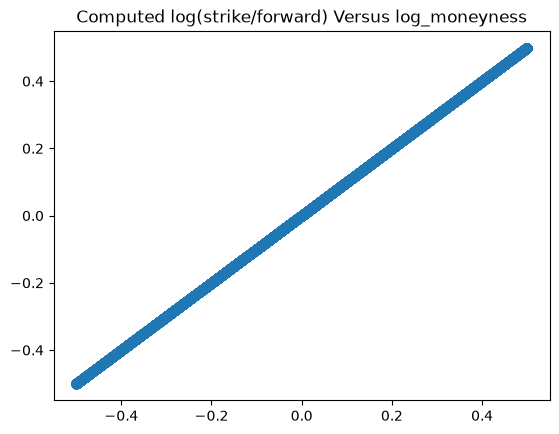

In [53]:
plt.scatter(raw_df["log_moneyness"], np.log(raw_df["strike"] / raw_df["forward"]));
plt.title("Computed log(strike/forward) Versus log_moneyness");

## Column: `type`

In [54]:
for type, count in raw_df["type"].value_counts().items():
    print(f"There are {count} rows about {type} options")

There are 408234 rows about put options
There are 270842 rows about call options


## Option Price Columns: `bid`, `ask`, `mid`

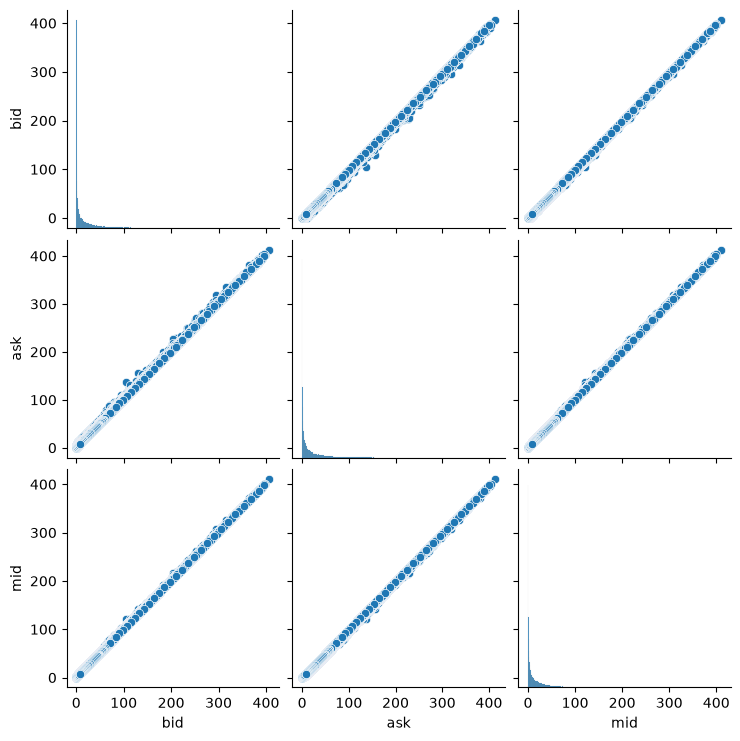

In [55]:
sns.pairplot(raw_df[["bid", "ask", "mid"]])

## Column: `iv`
I assume this is implied volatility, our target variable.

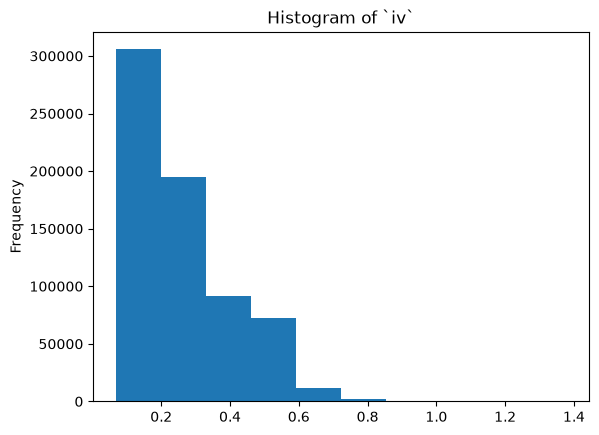

In [56]:
raw_df["iv"].plot(kind="hist")
plt.title("Histogram of `iv`");

## Column: `total_var`

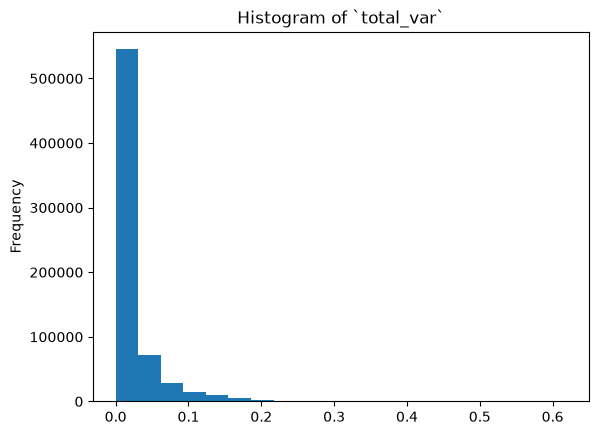

In [57]:
raw_df["total_var"].plot(kind="hist", bins=20)
plt.title("Histogram of `total_var`");

It seems amenable to a log transform:

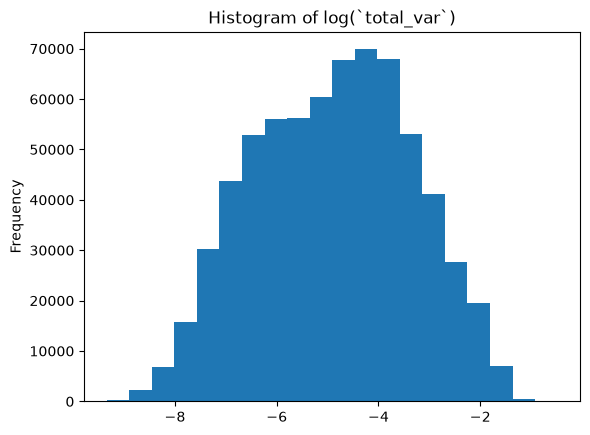

In [58]:
np.log(raw_df["total_var"]).plot(kind="hist", bins=20)
plt.title("Histogram of log(`total_var`)");

`total_var` seems to be obtained by $\tau\sigma^2$, where $\tau$ is `tau` and $\sigma$ is `iv`.

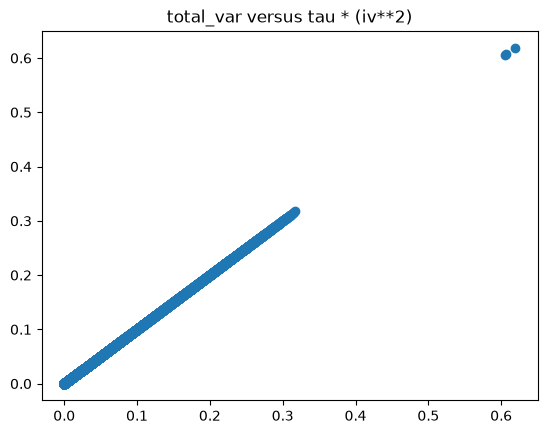

In [59]:
plt.scatter(raw_df["total_var"], raw_df["iv"]**2 * raw_df["tau"])
plt.title("total_var versus tau * (iv**2)");

## Column: `delta`
I assume this is the Black-Scholes delta

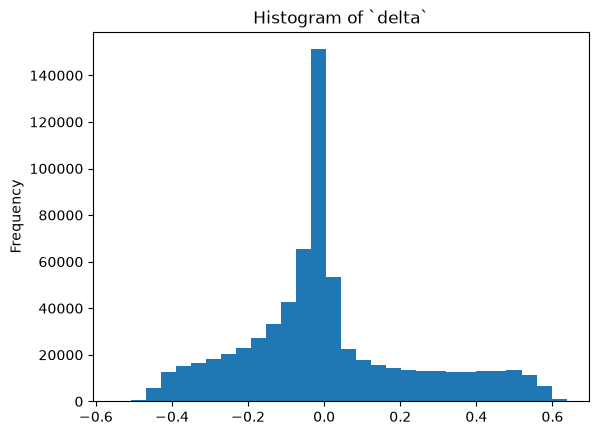

In [60]:
raw_df["delta"].plot(kind="hist", bins=30)
plt.title("Histogram of `delta`");

## Column: `volume`
**TODO**: look into the missing values in this column

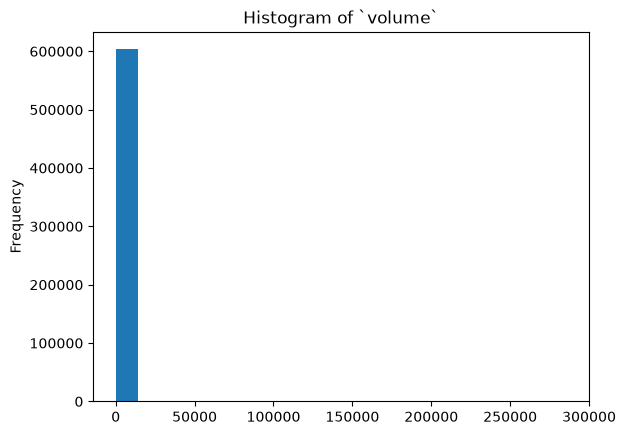

In [61]:
raw_df["volume"].plot(kind="hist", bins=20)
plt.title("Histogram of `volume`");

This column seems amenable to a log transform as well.

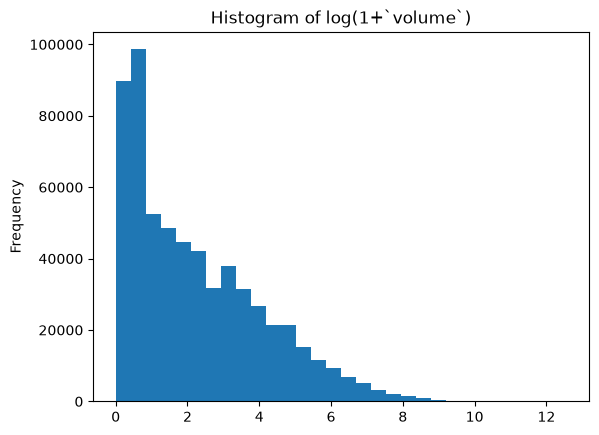

In [62]:
np.log1p(raw_df["volume"]).plot(kind="hist", bins=30)
plt.title("Histogram of log(1+`volume`)");

# Dataset comparison
There are three datasets: `surface_all.parquet`, `surface_test.parquet`, and `surface_train.parquet`.
This is a sanity check to make sure that the first is just the concatenation of the other two.

In [63]:
all_df = pd.read_parquet("Processed_data/surface_all.parquet")
test_df = pd.read_parquet("Processed_data/surface_test.parquet")
train_df = pd.read_parquet("Processed_data/surface_train.parquet")

# Check disjointness: no identical rows shared by train and test
join_cols = all_df.columns.tolist()
overlap_rows = train_df.merge(test_df, on=join_cols, how="inner")
is_disjoint = overlap_rows.empty

combined_df = pd.concat([train_df, test_df], ignore_index=True)

all_counts = all_df.value_counts(dropna=False).sort_index()
combined_counts = combined_df.value_counts(dropna=False).sort_index()
same_union = all_counts.equals(combined_counts)

print(f"Disjoint:             {is_disjoint}")
print(f"Union matches all_df: {same_union}")

Disjoint:             True
Union matches all_df: True


# The Smile

In [64]:
print(f"There are {len(raw_df.groupby(["ticker", "quote_date"]))} surfaces we can model in this dataset (grouped by ticker and date)")

There are 378 surfaces we can model in this dataset (grouped by ticker and date)


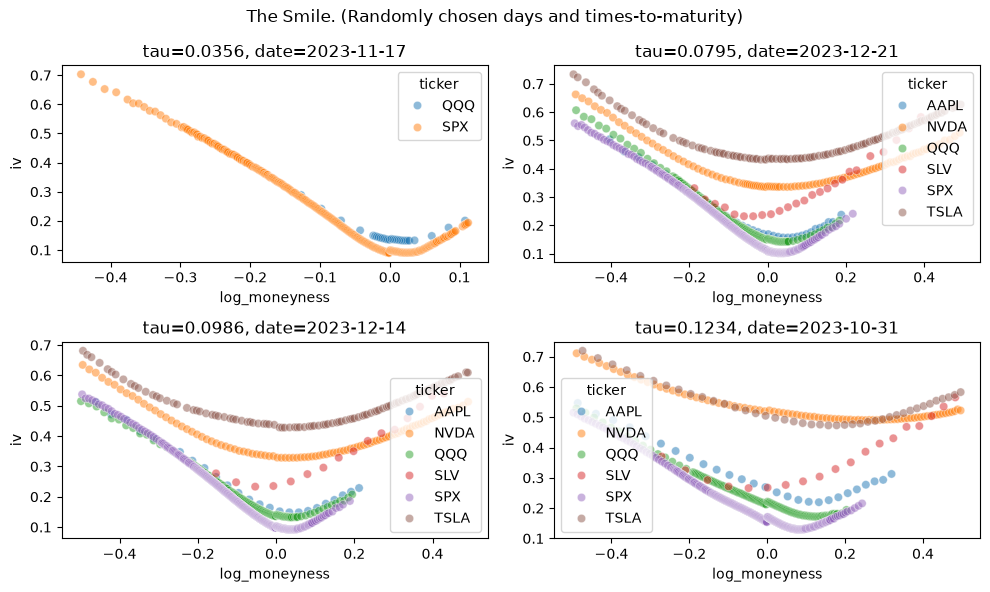

In [65]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6))
taus = raw_df["tau"].value_counts().index[:100] # 100 most common values of tau
# dates = np.random.choice(raw_df["quote_date"].unique(), 4)

for i, tau in enumerate(np.random.choice(taus, 4)):
    plot_df = raw_df[raw_df["tau"] == tau]
    date = plot_df["quote_date"].value_counts().index[0]
    plot_df = plot_df[plot_df["quote_date"] == date]
    # plot_df = plot_df[plot_df["quote_date"] == dates[i]]
    sns.scatterplot(plot_df, x="log_moneyness", y="iv", hue="ticker", ax=ax.flat[i], alpha=0.5)
    ax.flat[i].set_title(f"tau={tau:.4f}, date={date.strftime('%Y-%m-%d')}")
plt.suptitle("The Smile. (Randomly chosen days and times-to-maturity)")
plt.tight_layout()

## Is the function we're trying to model well-defined?

In [80]:
ticker_date_combos = list(raw_df.groupby(["ticker", "quote_date"]).size().index)

for i in range(len(ticker_date_combos)):
    ticker, date = ticker_date_combos[i]
    surface_df = raw_df[(raw_df["ticker"] == ticker) & (raw_df["quote_date"] == date)]
    if not all(surface_df.groupby(["dte", "strike"])["iv"].agg("count")==1):
        print(f"Ticker: {ticker:<4}  Date: {date}")

Ticker: NVDA  Date: 2023-12-06 00:00:00
Ticker: QQQ   Date: 2023-11-08 00:00:00
Ticker: SPX   Date: 2023-12-07 00:00:00


It looks like there are three instances in which the dataset gives more than one value of `iv`. This goes away when you also group by option type (put or call), so it seems like this is just a case in which the market does not exactly respect put-call parity. It's not a super prevalant issue, so we can ignore this for now.